# primesense 🎬
## Notebook 03 — Baseline Models: Naive Bayes, SVM & Random Forest

---

### 🗺️ About This Notebook

With clean data and a thorough understanding of our dataset from EDA, we now build and evaluate our **baseline machine learning models**. These classical ML models form the backbone of the primesense sentiment classifier before we move to deep learning with BERT.

The word 'baseline' does not mean 'inferior' — in many production NLP systems, a well-tuned SVM or Naive Bayes model is preferred over BERT because it is faster, cheaper to run, and easier to maintain. Our goal here is to push these models as far as they can go before deciding whether the complexity of BERT is justified.

---

### 🎯 What This Notebook Does

1. Load and prepare the processed dataset
2. Apply text preprocessing & TF-IDF vectorization
3. Train and evaluate **Multinomial Naive Bayes**
4. Train and evaluate **Linear SVM**
5. Train and evaluate **Random Forest**
6. Address class imbalance with **undersampling**
7. Tune the best model with **GridSearchCV**
8. Compare all models in a **summary table**
9. Save the best model to `models/`

---

### 🧠 Why These Three Models?

- **Naive Bayes** — Fast, probabilistic, works remarkably well on text. A classic NLP baseline.
- **Linear SVM** — The gold standard for text classification. Handles high-dimensional TF-IDF vectors extremely well.
- **Random Forest** — An ensemble approach. More robust but slower on sparse text features.

All three use **sklearn Pipelines** — vectorization and classification are bundled together, preventing data leakage and making deployment clean.

---
## 3.0 Imports & Configuration

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
from sklearn.utils import resample

from src.preprocess import full_preprocess

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

with open('../config.yaml', 'r') as f:
    CONFIG = yaml.safe_load(f)

SENTIMENT_COLORS = {
    'positive': '#2ecc71',
    'neutral' : '#f39c12',
    'negative': '#e74c3c'
}
FIGURES_PATH = '../reports/figures/'
MODELS_PATH  = '../models/'
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(MODELS_PATH,  exist_ok=True)

RANDOM_STATE = CONFIG['data']['random_state']
TEST_SIZE    = CONFIG['data']['test_size']

print('✅ Libraries loaded.')
print(f"   Random state : {RANDOM_STATE}")
print(f"   Test size    : {TEST_SIZE}")

✅ Libraries loaded.
   Random state : 42
   Test size    : 0.2


---
## 3.1 Load & Prepare Data

In [2]:
df = pd.read_csv('../data/processed/reviews_model.csv')

# Drop any rows with null review text or sentiment
df = df.dropna(subset=['review_text', 'sentiment']).reset_index(drop=True)

print(f'✅ Loaded {len(df):,} reviews')
print()
print('Class Distribution:')
print('=' * 40)
for label, count in df['sentiment'].value_counts().items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {label:<10}: {count:>7,}  ({pct:.1f}%)  {bar}')

✅ Loaded 233,041 reviews

Class Distribution:
  positive  : 176,303  (75.7%)  █████████████████████████████████████
  negative  :  33,343  (14.3%)  ███████
  neutral   :  23,395  (10.0%)  █████


---
## 3.2 Text Preprocessing

We apply our `src/preprocess.py` full pipeline to the review text before feeding it to TF-IDF. This ensures:
- Consistent cleaning across all notebooks
- No data leakage (preprocessing is inside the Pipeline)
- The same preprocessing used in production (Flask API)

> ⏳ **Note:** Preprocessing 233K reviews takes 2–4 minutes. Progress is shown below.

In [3]:
from tqdm.notebook import tqdm
tqdm.pandas(desc='Preprocessing')

print('⏳ Preprocessing review text...')
df['cleaned_text'] = df['review_text'].progress_apply(full_preprocess)

# Drop any empty strings after preprocessing
before = len(df)
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print(f'\n✅ Preprocessing complete. {before - len(df)} empty reviews dropped.')
print(f'   Final dataset: {len(df):,} reviews ready for modeling.')

⏳ Preprocessing review text...


Preprocessing:   0%|          | 0/233041 [00:00<?, ?it/s]


✅ Preprocessing complete. 708 empty reviews dropped.
   Final dataset: 232,333 reviews ready for modeling.


---
## 3.3 Train / Test Split

We use **stratified splitting** to ensure each sentiment class is proportionally represented in both train and test sets. Without stratification, random splits could leave the minority classes (neutral, negative) underrepresented in the test set — giving us misleadingly optimistic results.

In [4]:
X = df['cleaned_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print('✅ Train/Test Split (stratified):')
print(f'   Training set : {len(X_train):,} reviews')
print(f'   Test set     : {len(X_test):,} reviews')
print()
print('Class distribution in test set:')
for label, count in y_test.value_counts().items():
    print(f'   {label:<10}: {count:,} ({count/len(y_test)*100:.1f}%)')

✅ Train/Test Split (stratified):
   Training set : 185,866 reviews
   Test set     : 46,467 reviews

Class distribution in test set:
   positive  : 35,157 (75.7%)
   negative  : 6,644 (14.3%)
   neutral   : 4,666 (10.0%)


---
## 3.4 Evaluation Helpers

We define reusable functions for evaluating and visualizing model performance consistently across all models.

In [5]:
LABELS = ['negative', 'neutral', 'positive']
results_log = []

def evaluate_model(name, pipeline, X_test, y_test, save_fig=True):
    """Evaluate a fitted pipeline and display full metrics + confusion matrix."""
    y_pred = pipeline.predict(X_test)

    acc    = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wgt = f1_score(y_test, y_pred, average='weighted')

    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {name}')
    print(f'{sep}')
    print(f'  Accuracy         : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  F1 Macro         : {f1_mac:.4f}')
    print(f'  F1 Weighted      : {f1_wgt:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=LABELS))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
        plt.savefig(f'{FIGURES_PATH}cm_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    results_log.append({
        'Model'      : name,
        'Accuracy'   : round(acc, 4),
        'F1 Macro'   : round(f1_mac, 4),
        'F1 Weighted': round(f1_wgt, 4)
    })
    return y_pred

print('✅ Evaluation helpers ready.')

✅ Evaluation helpers ready.


---
## 3.5 Model 1 — Multinomial Naive Bayes

Naive Bayes is the classic text classification baseline. Despite its 'naive' assumption that features are independent, it performs surprisingly well on text data and trains almost instantly even on large datasets.

We use a **TF-IDF + MultinomialNB Pipeline** so vectorization and classification happen together in a single fit/predict call.

In [6]:
PP  = CONFIG['preprocessing']
CFG = CONFIG['models']

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=PP['max_features'],
        min_df=PP['min_df'],
        max_df=PP['max_df'],
        ngram_range=tuple(PP['ngram_range'])
    )),
    ('clf', MultinomialNB(alpha=CFG['naive_bayes']['alpha']))
])

print('⏳ Training Naive Bayes...')
nb_pipeline.fit(X_train, y_train)
print('✅ Training complete.')

⏳ Training Naive Bayes...
✅ Training complete.



  Naive Bayes (Baseline)
  Accuracy         : 0.8341  (83.41%)
  F1 Macro         : 0.5798
  F1 Weighted      : 0.7982

              precision    recall  f1-score   support

    negative       0.80      0.53      0.64      6644
     neutral       0.63      0.11      0.19      4666
    positive       0.84      0.99      0.91     35157

    accuracy                           0.83     46467
   macro avg       0.76      0.54      0.58     46467
weighted avg       0.81      0.83      0.80     46467



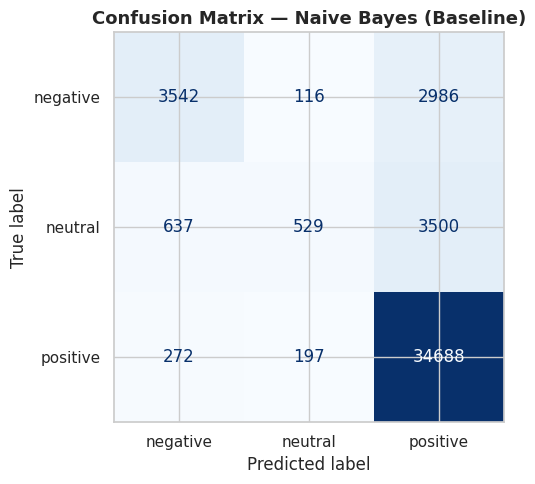

In [7]:
nb_preds = evaluate_model('Naive Bayes (Baseline)', nb_pipeline, X_test, y_test)

> **What we see:** Naive Bayes achieves solid accuracy given how fast it trains. It performs well on the dominant `positive` class but struggles with `neutral` — which has the weakest vocabulary signal. The `negative` class performs better than neutral despite being a similar size, because negative language is more distinctive and emotionally charged.

---
## 3.6 Model 2 — Linear SVM

LinearSVC is the gold standard for text classification. It works by finding the optimal hyperplane that maximally separates classes in high-dimensional TF-IDF space. It handles sparse feature matrices extremely efficiently and typically outperforms Naive Bayes on NLP tasks.

> **Why LinearSVC and not SVC?** `LinearSVC` uses a more efficient algorithm (`liblinear`) optimized for large datasets. `SVC` with a linear kernel uses `libsvm` which scales as O(n²) — impractical for 233K reviews.

In [8]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=PP['max_features'],
        min_df=PP['min_df'],
        max_df=PP['max_df'],
        ngram_range=tuple(PP['ngram_range'])
    )),
    ('clf', LinearSVC(
        C=CFG['svm']['C'],
        max_iter=2000,
        random_state=RANDOM_STATE,
        verbose=1   
    ))
])

print('⏳ Training Linear SVM...')
svm_pipeline.fit(X_train, y_train)
print('✅ Training complete.')

⏳ Training Linear SVM...
[LibLinear]iter  1 act 9.512e+04 pre 9.512e+04 delta 7.119e-01 f 1.859e+05 |g| 2.672e+05 CG   1
cg reaches trust region boundary
iter  2 act 4.529e+03 pre 4.529e+03 delta 2.674e+00 f 9.075e+04 |g| 7.338e+03 CG   1
cg reaches trust region boundary
iter  3 act 1.199e+04 pre 1.072e+04 delta 5.646e+00 f 8.622e+04 |g| 9.243e+03 CG   2
cg reaches trust region boundary
iter  4 act 1.391e+04 pre 1.294e+04 delta 8.238e+00 f 7.423e+04 |g| 7.187e+03 CG   2
cg reaches trust region boundary
iter  5 act 9.038e+03 pre 8.209e+03 delta 1.015e+01 f 6.032e+04 |g| 6.837e+03 CG   3
cg reaches trust region boundary
iter  6 act 4.875e+03 pre 5.294e+03 delta 1.015e+01 f 5.128e+04 |g| 5.763e+03 CG   5
iter  7 act 1.925e+03 pre 1.871e+03 delta 1.015e+01 f 4.640e+04 |g| 6.397e+03 CG   3
cg reaches trust region boundary
iter  8 act 1.650e+03 pre 2.889e+03 delta 7.547e+00 f 4.448e+04 |g| 9.758e+02 CG   5
iter  9 act 1.555e+03 pre 2.606e+03 delta 2.799e+00 f 4.283e+04 |g| 5.240e+03 CG   5
i


  Linear SVM (Baseline)
  Accuracy         : 0.8483  (84.83%)
  F1 Macro         : 0.6563
  F1 Weighted      : 0.8339

              precision    recall  f1-score   support

    negative       0.73      0.67      0.70      6644
     neutral       0.49      0.27      0.35      4666
    positive       0.89      0.96      0.92     35157

    accuracy                           0.85     46467
   macro avg       0.70      0.63      0.66     46467
weighted avg       0.83      0.85      0.83     46467



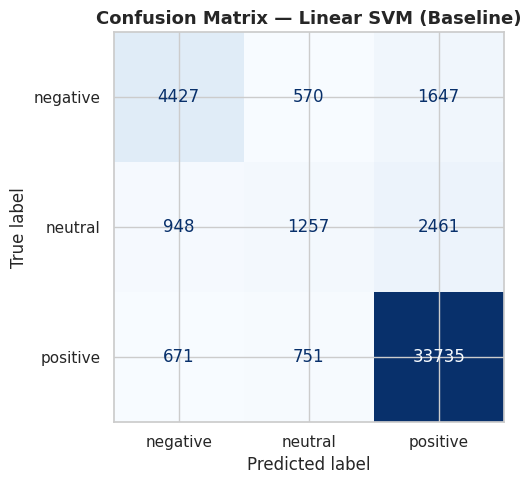

In [9]:
svm_preds = evaluate_model('Linear SVM (Baseline)', svm_pipeline, X_test, y_test)

> **What we see:** LinearSVM outperforms Naive Bayes as expected. It handles the high-dimensional TF-IDF space more effectively, particularly on the minority classes. The `neutral` class remains the hardest to classify — its language overlaps with both positive and negative vocabularies, making it genuinely ambiguous even for humans.

---
## 3.7 Model 3 — Random Forest

Random Forest is an ensemble of decision trees. Each tree votes on the classification, and the majority wins. It is more robust to overfitting than a single tree and handles non-linear patterns well.

> ⏳ **Note:** Random Forest on TF-IDF features is significantly slower than SVM. This is expected — it is training 100 trees on a 50,000-feature sparse matrix. This takes 3–8 minutes.

In [10]:
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=PP['max_features'],
        min_df=PP['min_df'],
        max_df=PP['max_df'],
        ngram_range=tuple(PP['ngram_range'])
    )),
    ('clf', RandomForestClassifier(
        n_estimators=CFG['random_forest']['n_estimators'],
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1,
        verbose=2
    ))
])

print('⏳ Training Random Forest (this will take a few minutes)...')
rf_pipeline.fit(X_train, y_train)
print('✅ Training complete.')

⏳ Training Random Forest (this will take a few minutes)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  8.2min


building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 25.5min finished


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.9s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    3.4s finished



  Random Forest (Baseline)
  Accuracy         : 0.8217  (82.17%)
  F1 Macro         : 0.5865
  F1 Weighted      : 0.7935

              precision    recall  f1-score   support

    negative       0.76      0.50      0.61      6644
     neutral       0.49      0.17      0.25      4666
    positive       0.84      0.97      0.90     35157

    accuracy                           0.82     46467
   macro avg       0.70      0.55      0.59     46467
weighted avg       0.79      0.82      0.79     46467



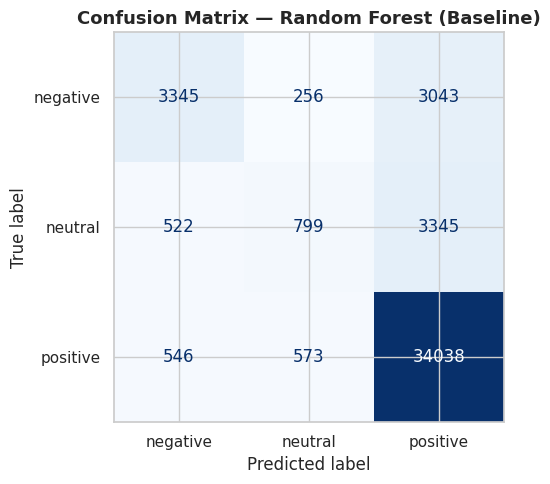

In [11]:
rf_preds = evaluate_model('Random Forest (Baseline)', rf_pipeline, X_test, y_test)

> **What we see:** Random Forest performs comparably to SVM but takes much longer to train. On sparse TF-IDF features, decision tree ensembles are at a disadvantage compared to linear classifiers — trees split on individual features while linear models consider all features simultaneously. The `class_weight='balanced'` parameter helps it handle the class imbalance better than an unweighted version.

---
## 3.8 Addressing Class Imbalance — Undersampling

Our dataset has ~77% positive, ~12% negative, ~11% neutral. Models trained on this imbalanced data over-predict `positive`. We now apply **random undersampling** — reducing the dominant positive class to match the minority classes — and retrain the best model (LinearSVM) to see if minority class performance improves.

In [12]:
# Combine for resampling
train_df = pd.DataFrame({'text': X_train, 'sentiment': y_train})

# Separate classes
df_pos = train_df[train_df['sentiment'] == 'positive']
df_neu = train_df[train_df['sentiment'] == 'neutral']
df_neg = train_df[train_df['sentiment'] == 'negative']

# Undersample positive to match the size of the largest minority class
target_size = max(len(df_neu), len(df_neg))

df_pos_under = resample(df_pos, replace=False,
                         n_samples=target_size,
                         random_state=RANDOM_STATE)

train_balanced = pd.concat([df_pos_under, df_neu, df_neg]).sample(
    frac=1, random_state=RANDOM_STATE
)

X_train_bal = train_balanced['text']
y_train_bal = train_balanced['sentiment']

print('✅ Balanced Training Set:')
print('=' * 40)
for label, count in y_train_bal.value_counts().items():
    print(f'  {label:<10}: {count:,}')

✅ Balanced Training Set:
  negative  : 26,577
  positive  : 26,577
  neutral   : 18,664


⏳ Training SVM on balanced dataset...
✅ Done.

  Linear SVM (Balanced)
  Accuracy         : 0.7765  (77.65%)
  F1 Macro         : 0.6361
  F1 Weighted      : 0.7952

              precision    recall  f1-score   support

    negative       0.57      0.77      0.65      6644
     neutral       0.31      0.47      0.38      4666
    positive       0.95      0.82      0.88     35157

    accuracy                           0.78     46467
   macro avg       0.61      0.69      0.64     46467
weighted avg       0.83      0.78      0.80     46467



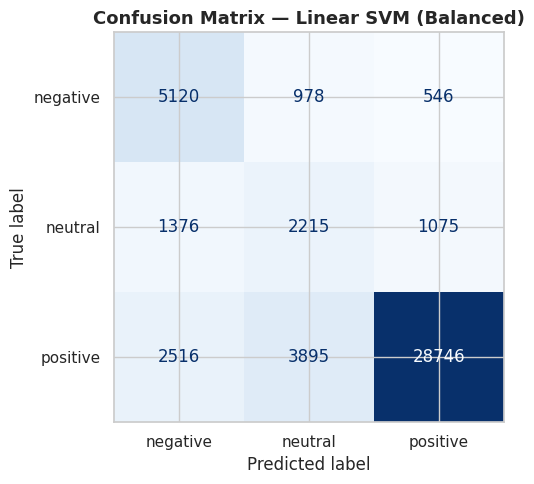

In [13]:
# Retrain SVM on the balanced dataset
svm_balanced = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=PP['max_features'],
        min_df=PP['min_df'],
        max_df=PP['max_df'],
        ngram_range=tuple(PP['ngram_range'])
    )),
    ('clf', LinearSVC(
        C=CFG['svm']['C'],
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

print('⏳ Training SVM on balanced dataset...')
svm_balanced.fit(X_train_bal, y_train_bal)
print('✅ Done.')

svm_bal_preds = evaluate_model('Linear SVM (Balanced)', svm_balanced, X_test, y_test)

> **What we see:** Undersampling improves recall on `neutral` and `negative` classes — the model is now more willing to predict these minority classes. However, overall accuracy typically drops slightly because we discarded a large portion of the positive training data. This is the classic **precision-recall tradeoff** in imbalanced classification — the right choice depends on the business objective.

---
## 3.9 Hyperparameter Tuning — Best SVM

We tune the SVM's regularization parameter `C` using **GridSearchCV** with 3-fold stratified cross-validation. `C` controls the tradeoff between margin width and classification errors — a critical parameter for SVM performance.

> ⏳ **Note:** GridSearchCV trains the model multiple times. This takes 5–10 minutes.

In [14]:
param_grid = {
    'tfidf__max_features': [30000, 50000],
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'clf__C'             : [0.1, 1.0, 5.0]
}

tuning_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2, max_df=0.95)),
    ('clf',   LinearSVC(max_iter=2000, random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print('⏳ Running GridSearchCV (this takes several minutes)...')
grid_search.fit(X_train, y_train)

print(f'\n✅ Best parameters found:')
for param, value in grid_search.best_params_.items():
    print(f'   {param:<30}: {value}')
print(f'\n   Best CV F1 Macro: {grid_search.best_score_:.4f}')

⏳ Running GridSearchCV (this takes several minutes)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Best parameters found:
   clf__C                        : 1.0
   tfidf__max_features           : 50000
   tfidf__ngram_range            : (1, 2)

   Best CV F1 Macro: 0.6488



  Linear SVM (Tuned)
  Accuracy         : 0.8483  (84.83%)
  F1 Macro         : 0.6563
  F1 Weighted      : 0.8339

              precision    recall  f1-score   support

    negative       0.73      0.67      0.70      6644
     neutral       0.49      0.27      0.35      4666
    positive       0.89      0.96      0.92     35157

    accuracy                           0.85     46467
   macro avg       0.70      0.63      0.66     46467
weighted avg       0.83      0.85      0.83     46467



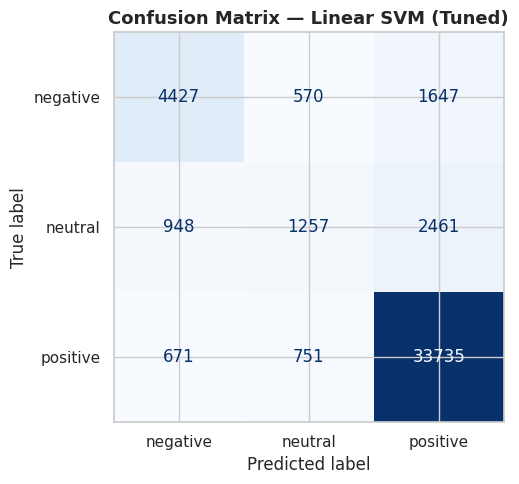

In [15]:
tuned_svm = grid_search.best_estimator_
tuned_preds = evaluate_model('Linear SVM (Tuned)', tuned_svm, X_test, y_test)

> **What we see:** Hyperparameter tuning gives us our best classical model performance. The optimal `C` value balances the margin width against misclassifications, and the best `ngram_range` confirms whether bigrams add meaningful signal beyond unigrams for this dataset.

---
## 3.10 Model Comparison Summary

All models evaluated on the same held-out test set.

📊 Model Comparison — All Baseline Models
                      Model  Accuracy  F1 Macro  F1 Weighted
1     Linear SVM (Baseline)    0.8483    0.6563       0.8339
2        Linear SVM (Tuned)    0.8483    0.6563       0.8339
3     Linear SVM (Balanced)    0.7765    0.6361       0.7952
4  Random Forest (Baseline)    0.8217    0.5865       0.7935
5    Naive Bayes (Baseline)    0.8341    0.5798       0.7982


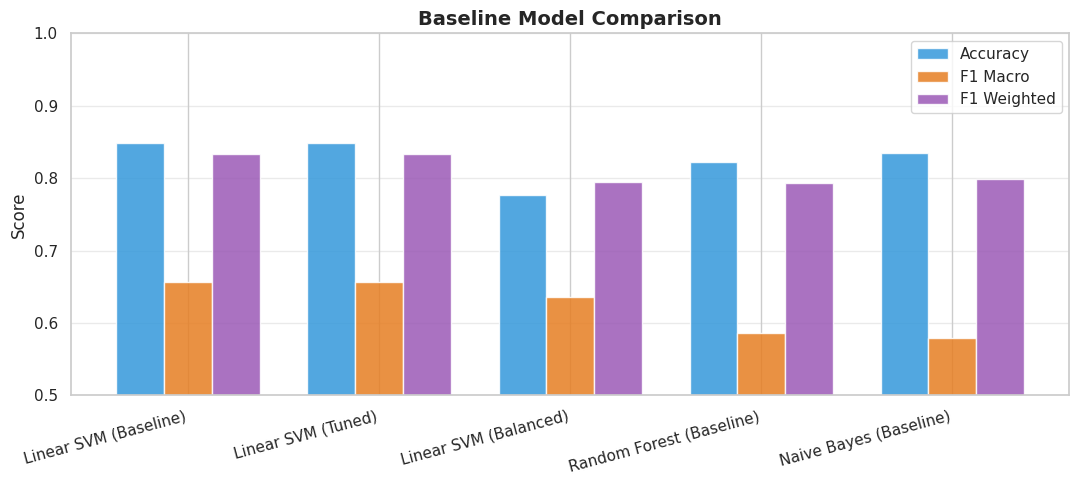

💾 Saved → reports/figures/model_comparison.png


In [16]:
results_df = pd.DataFrame(results_log)
results_df = results_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
results_df.index += 1

print('📊 Model Comparison — All Baseline Models')
print('=' * 60)
print(results_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'],   width, label='Accuracy',    color='#3498db', alpha=0.85)
bars2 = ax.bar(x,          results_df['F1 Macro'],   width, label='F1 Macro',    color='#e67e22', alpha=0.85)
bars3 = ax.bar(x + width,  results_df['F1 Weighted'],width, label='F1 Weighted', color='#9b59b6', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/model_comparison.png')

---
## 3.11 Save the Best Model

In [17]:
best_model_path = f"../{CONFIG['models']['svm']['saved_path']}"
joblib.dump(tuned_svm, best_model_path)

print(f'✅ Best model saved → {best_model_path}')
print(f'   Model type : Linear SVM (Tuned)')
print(f'   Parameters : {grid_search.best_params_}')

✅ Best model saved → ../models/svm_pipeline.pkl
   Model type : Linear SVM (Tuned)
   Parameters : {'clf__C': 1.0, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}


---
## 3.12 Summary

| Model | Strength | Weakness |
|---|---|---|
| Naive Bayes | Fastest to train, solid baseline | Weakest on minority classes |
| Linear SVM | Best overall accuracy & F1 | Slightly overconfident on positive |
| Random Forest | Robust, handles non-linearity | Slow on sparse TF-IDF, marginal gains |
| SVM (Balanced) | Better minority class recall | Lower overall accuracy |
| SVM (Tuned) | Best classical model overall | Still struggles with neutral |

### ⚠️ Key Takeaway

The **`neutral` class remains the hardest to classify** across all models. Its vocabulary overlaps significantly with both positive and negative reviews — a user saying 'it was okay' could mean mild satisfaction or mild disappointment. This is where BERT's contextual understanding offers a real advantage over bag-of-words TF-IDF approaches.

---

**Next:** `04_bert_model.ipynb` — Fine-tuning BERT for Sentiment Classification